In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Data load
heart_data = pd.read_csv('/content/heart.csv')

# **EDA**

In [ ]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
heart_data.shape

(303, 14)

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
heart_data.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,False,False,False,False
300,False,False,False,False,False,False,False,False,False,False,False,False,False,False
301,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
heart_data.duplicated().sum()

np.int64(1)

In [ ]:
heart_data.drop_duplicates(inplace=True)

In [ ]:
heart_data.shape

(302, 14)

In [ ]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
heart_data['target'].value_counts()

,count
target,
1,164
0,138


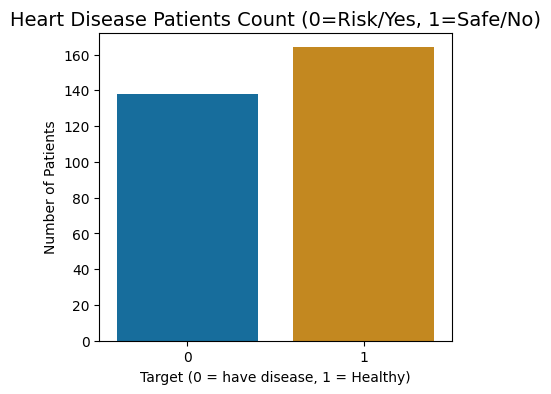

In [ ]:
plt.figure(figsize=(10, 4))
# Kitne logo ko bimari hai aur kitno ko nahi
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=heart_data, palette='colorblind')
plt.title('Heart Disease Patients Count (0=Risk/Yes, 1=Safe/No)', fontsize=14)
plt.xlabel('Target (0 = have disease, 1 = Healthy)')
plt.ylabel('Number of Patients')
plt.show()

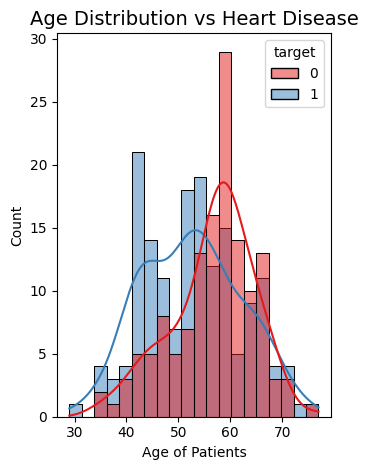

In [ ]:
# Age ke hisaab se bimari ka relation
plt.subplot(1, 2, 2)
sns.histplot(data=heart_data, x='age', hue='target', kde=True, palette='Set1', bins=20)
plt.title('Age Distribution vs Heart Disease', fontsize=14)
plt.xlabel('Age of Patients')
plt.tight_layout()
plt.show()

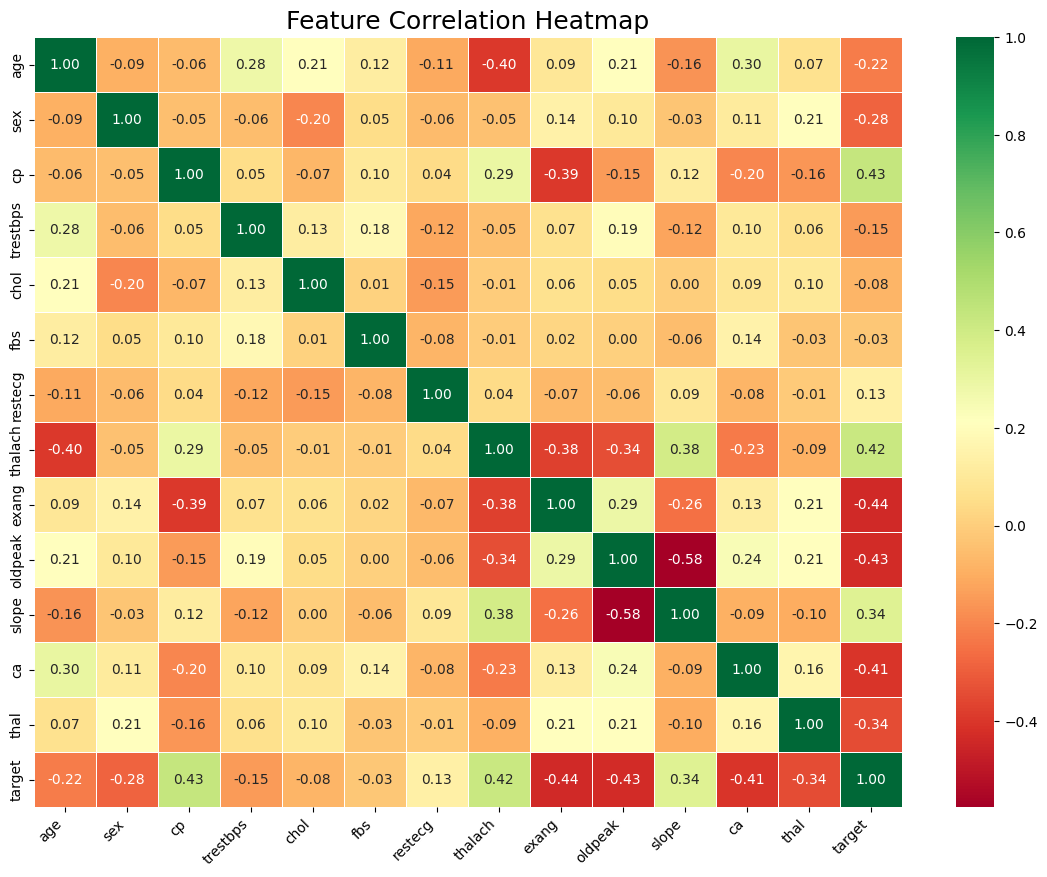

In [ ]:
# Correlation graph (Heatmap)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heart_data.corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=.5, ax=ax)

# Graph ki styling
plt.title('Feature Correlation Heatmap', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# extra column (fbs) hataya
heart_data = heart_data.drop(columns=['fbs'])

In [ ]:
# one hot encoding used
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True)

In [ ]:
# Features (X) aur Target (Y) ko alag karo
X = heart_data.drop(columns=['target'])
Y = heart_data['target']

In [ ]:
heart_data

,age,sex,trestbps,chol,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,150,0,2.3,0,1,False,False,True,False,False,False,False,True,False,False
1,37,1,130,250,187,0,3.5,0,1,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,172,0,1.4,0,1,True,False,False,False,False,False,True,False,True,False
3,56,1,120,236,178,0,0.8,0,1,True,False,False,True,False,False,True,False,True,False
4,57,0,120,354,163,1,0.6,0,1,False,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,123,1,0.2,0,0,False,False,False,True,False,True,False,False,False,True
299,45,1,110,264,132,0,1.2,0,0,False,False,True,True,False,True,False,False,False,True
300,68,1,144,193,141,0,3.4,2,0,False,False,False,True,False,True,False,False,False,True
301,57,1,130,131,115,1,1.2,1,0,False,False,False,True,False,True,False,False,False,True


In [ ]:
# Data ko Train (80%) aur Test (20%) me batao
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)
print(X.shape,X_train.shape,X_test.shape)

(302, 18) (241, 18) (61, 18)


In [ ]:
# Data Scaling
scaler = StandardScaler()
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

#model training


In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model use
model = LogisticRegression(max_iter=1000, random_state=42)
# Model ko 'fit' kra
model.fit(X_train, Y_train)
print("training completed...")

training completed...


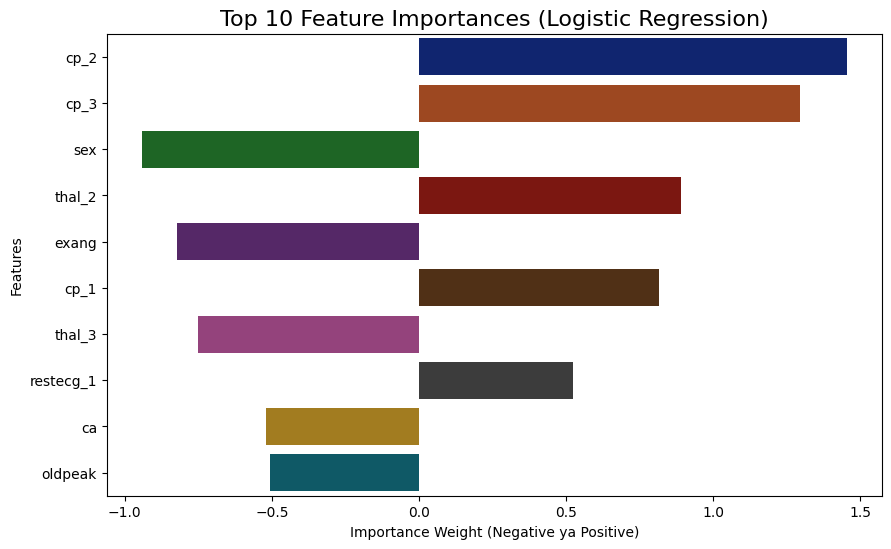

In [ ]:
# Logistic Regression ke 'coefficients'
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.coef_[0]
})
# sort in descending order
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

# graph draw
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='dark')
plt.title('Top 10 Feature Importances (Logistic Regression)', fontsize=16)
plt.xlabel('Importance Weight (Negative ya Positive)')
plt.ylabel('Features')
plt.show()

# **Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# make prediction on test data
Y_pred = model.predict(X_test)
# Accuracy Score
accuracy = accuracy_score(Y_test, Y_pred)
print("Model's Accuracy:", round(accuracy * 100, 2), "%")
# Detailed report
print("\n--- Classification Report ---")
print(classification_report(Y_test, Y_pred))

Model's Accuracy: 78.69 %

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        28
           1       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



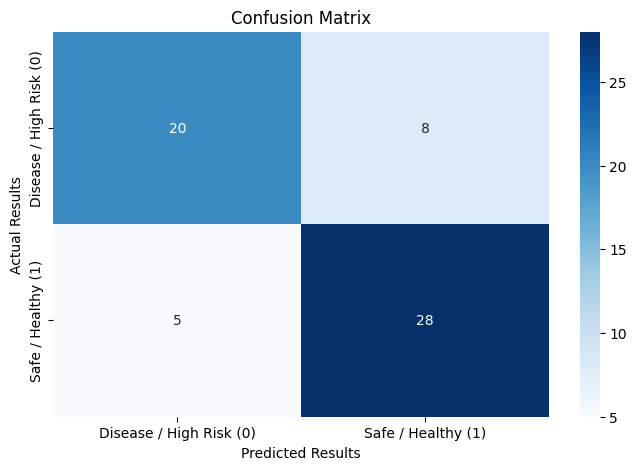

In [ ]:
from sklearn.metrics import confusion_matrix
# data calculate
cm = confusion_matrix(Y_test, Y_pred)
# Graph Plot
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Disease / High Risk (0)', 'Safe / Healthy (1)'],
            yticklabels=['Disease / High Risk (0)', 'Safe / Healthy (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Results')
plt.xlabel('Predicted Results')
plt.show()

# **Build Predictive System**

In [ ]:
# new patient test
patient_data = {
        'age': 59,
        'sex': 1,
        'cp': 3,
        'trestbps': 160,
        'chol': 273,
        'restecg': 0,
        'thalach': 125,
        'exang': 0,
        'oldpeak': 0,
        'slope': 2,
        'ca': 0,
        'thal': 2
    }

In [ ]:
# DataFrame
patient_df = pd.DataFrame([patient_data])

# One-Hot Encoding
patient_df = pd.get_dummies(patient_df, columns=['cp', 'restecg', 'slope', 'thal'])

# missing col fill
for col in X_train.columns:
    if col not in patient_df.columns:
        patient_df[col] = 0

# make column's sequence exact X_train
patient_df = patient_df[X_train.columns]

# Data Scaling
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
patient_df[numerical_cols] = scaler.transform(patient_df[numerical_cols])

# Final Prediction
prediction = model.predict(patient_df)
probability = model.predict_proba(patient_df)

In [ ]:
print("="*40)
print("🩺 REAL-LIFE PATIENT DIAGNOSIS REPORT 🩺")
print("="*40)

🩺 REAL-LIFE PATIENT DIAGNOSIS REPORT 🩺


In [ ]:
if prediction[0] == 0:
    print("⚠️ WARNING: According to the model, this patient is at HIGH RISK of Heart Disease.")
    print(f"Probability of having the disease: {round(probability[0][0] * 100, 2)}%")
else:
    print("✅ SAFE: According to the model, this patient's heart appears to be healthy.")
    print(f"Probability of being safe: {round(probability[0][1] * 100, 2)}%")
print("="*40)

✅ SAFE: According to the model, this patient's heart appears to be healthy.
Probability of being safe: 79.35%
